# Fotogrametría: Reconstrucción 3D de objetos

In [117]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import rembg
import os
from os.path import dirname, join, abspath

## Preprocesado

In [118]:
BASE_DIR = 'Samples'
SRC_SUBDIR = join('04_Samples', '00_state')
TARGET_SUBDIR = join('04_Samples', '01_state')
TARGET_DIR = join(BASE_DIR, TARGET_SUBDIR)

img_paths = [
    join(BASE_DIR, SRC_SUBDIR, f'{i:02d}_model.jpeg')
    for i in range(1, 12)
]

# Depuracion: Esto es pa ver si existen las imágenes
img_paths = [p for p in img_paths if os.path.exists(p)]
if len(img_paths) == 0:
    print('No se encontraron imágenes en las rutas configuradas')

# Parámetro gamma no lo toqueis porque hasta ahora es el mejor
gamma = 2.0

def rembg_remove_np(img):

    ok, buf = cv.imencode('.png', img) # codifica a PNG. ok dice si ha ido bien y buf es un array bytes

    if not ok:
        raise RuntimeError('Error al codificar la imagen a PNG')
    
    out_bytes = rembg.remove(buf.tobytes()) # .tobytes() convierte a bytes
    out_arr = np.frombuffer(out_bytes, dtype=np.uint8) #  combierte bytes a array
    out_img = cv.imdecode(out_arr, cv.IMREAD_UNCHANGED)  # pasa de array a imagen de openCV
    return out_img

def apply_gamma(img, gamma_val):
    # Aplica corrección gamma y devuelve imagen uint8
    img_f = img.astype(np.float32) / 255.0
    out = np.clip(255.0 * np.power(img_f, gamma_val), 0, 255).astype(np.uint8)
    return out

os.makedirs(TARGET_DIR, exist_ok=True) # crea el directorio de salida si no existe


for src_path in img_paths:
    filename = os.path.basename(src_path)
    name_noext = os.path.splitext(filename)[0]
    print(f'Procesando {filename}...')

    # leer original
    img = cv.imread(src_path)
    if img is None:
        print(f'  Error leyendo {src_path}, pasamos al siguiente.')
        continue

    # aplicar corrección gamma
    img_exp = apply_gamma(img, gamma)

    # aplicar rembg sobre la imagen exp
    try:
        out = rembg_remove_np(img_exp)
    except Exception as e:
        print(f'  Error rembg sobre {filename}: {e}')
        out = None

    # Guardamos el resultado
    out_name = f'{name_noext}.png'
    out_path = join(TARGET_DIR, out_name)

    if out is None:
        print(f'  No se generó salida para {filename}, deberías repetir el proceso.')
        # Guardar la imagen exp original como fallback (sin alpha)
        cv.imwrite(out_path, img_exp)
    else:
        # Si rembg devuelve una imagen con 4 canales (BGRA) o 3 canales
        # cv.imwrite maneja ambos casos
        written = cv.imwrite(out_path, out)
        if not written:
            print(f'  Error escribiendo {out_path}, deberías repetir el proceso.')
            cv.imwrite(out_path, img_exp)

    print(f'  Guardado -> {out_path}')

print('Procesamiento completado.')

Procesando 01_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/01_model.png
Procesando 02_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/02_model.png
Procesando 03_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/03_model.png
Procesando 04_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/04_model.png
Procesando 05_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/05_model.png
Procesando 06_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/06_model.png
Procesando 07_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/07_model.png
Procesando 08_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/08_model.png
Procesando 09_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/09_model.png
Procesando 10_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/10_model.png
Procesando 11_model.jpeg...
  Guardado -> Samples/04_Samples/01_state/11_model.png
Procesamiento completado.


In [119]:
img_gray = []
imgs_clean = []
for i in range(1,12):
  img_path = "Samples/04_Samples/01_state/"+f"{i:02d}_model.png"
  img = cv.imread(img_path,cv.IMREAD_UNCHANGED)
  img[(img[:,:,3]==0)] = [255,255,255,255]
  img = img[:,:,:3]
  img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
  if img is None:
    print(f"No se pudo cargar la imagen {img_path}")
    continue
  imgs_clean.append(img)


## Extracción y detección de características

In [127]:
def feature_and_matching(im1, im2):
    # Inicializa el detector SIFT (Scale-Invariant Feature Transform)
    # SIFT es robusto a cambios de escala y rotación.
    sift = cv.SIFT_create()

    # 1. Detección de Puntos Clave (Keypoints) y Descriptores
    # kp: Puntos clave (coordenadas, escala, orientación)
    # des: Descriptores (vector de 128 elementos que describen la región del keypoint)
    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    # 2. Emparejamiento de Descriptores (Feature Matching)
    # Inicializa el 'Brute-Force Matcher'.
    # Usamos FLANN o BFMatcher para encontrar la correspondencia más cercana entre descriptores.
    bf = cv.BFMatcher()

    # Aplica knnMatch (k=2) para encontrar los 2 mejores matches para cada descriptor.
    # Esto es necesario para la prueba del ratio de Lowe.
    matches = bf.knnMatch(des1, des2, k=2)
    
    # 3. Filtrado de Matches con el Test de Ratio de Lowe
    # Un match es "bueno" si la distancia al mejor match (m) es significativamente menor 
    # que la distancia al segundo mejor match (n).
    good_matches = []
    ratio_threshold = 0.7 # Valor común: 0.7 o 0.75
    
    for m, n in matches:
        if m.distance < n.distance * ratio_threshold:
            good_matches.append(m)

    # 4. Extracción de Coordenadas de los Puntos Emparejados
    matches = good_matches
    
    # pts1 y pts2 contienen las coordenadas (x, y) de los puntos emparejados, 
    # donde el punto en la posición "i" de pts1 está emparejado con el punto en la posición"i" de pts2.
    # Usamos np.float32 para la precisión geométrica y el formato (N, 2).

    pts1 = np.float32([kp1[p.queryIdx].pt for p in matches])
    pts2 = np.float32([kp2[p.trainIdx].pt for p in matches])

    # Devolvemos los puntos emparejados
    return pts1, pts2, kp1, kp2, good_matches


--- DATOS DEL MATCHING ---
Total puntos encontrados en Imagen 1: 304
Total puntos encontrados en Imagen 2: 347
Coincidencias (Matches) tras filtro:  32
Forma de la matriz de puntos 1:       (32, 2)
--------------------------


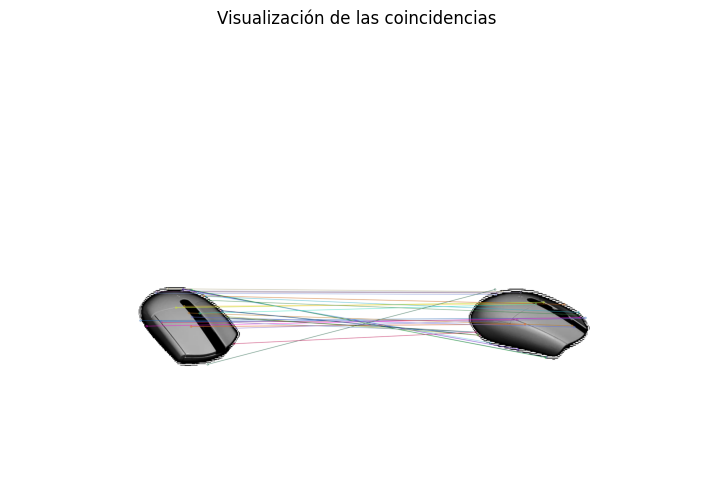

In [128]:
# 1. Seleccionamos dos imágenes
img1 = imgs_clean[0]
img2 = imgs_clean[1]

# 2. Ejecutamos tu función corregida
pts1, pts2, kp1, kp2,matches = feature_and_matching(img1, img2)

# --- DATOS QUE NOS INTERESAN ---
print(f"--- DATOS DEL MATCHING ---")
print(f"Total puntos encontrados en Imagen 1: {len(kp1)}")
print(f"Total puntos encontrados en Imagen 2: {len(kp2)}")
print(f"Coincidencias (Matches) tras filtro:  {len(matches)}")
print(f"Forma de la matriz de puntos 1:       {pts1.shape}") # Debería ser (N, 2)
print(f"--------------------------")

# 3. Visualización simple (Solo las primeras 50 líneas para ver claro)
res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)

plt.figure(figsize=(15, 6))
plt.title("Visualización de las coincidencias")
plt.imshow(res)
plt.axis('off')
plt.show()

## Sfm: Structure from Motion

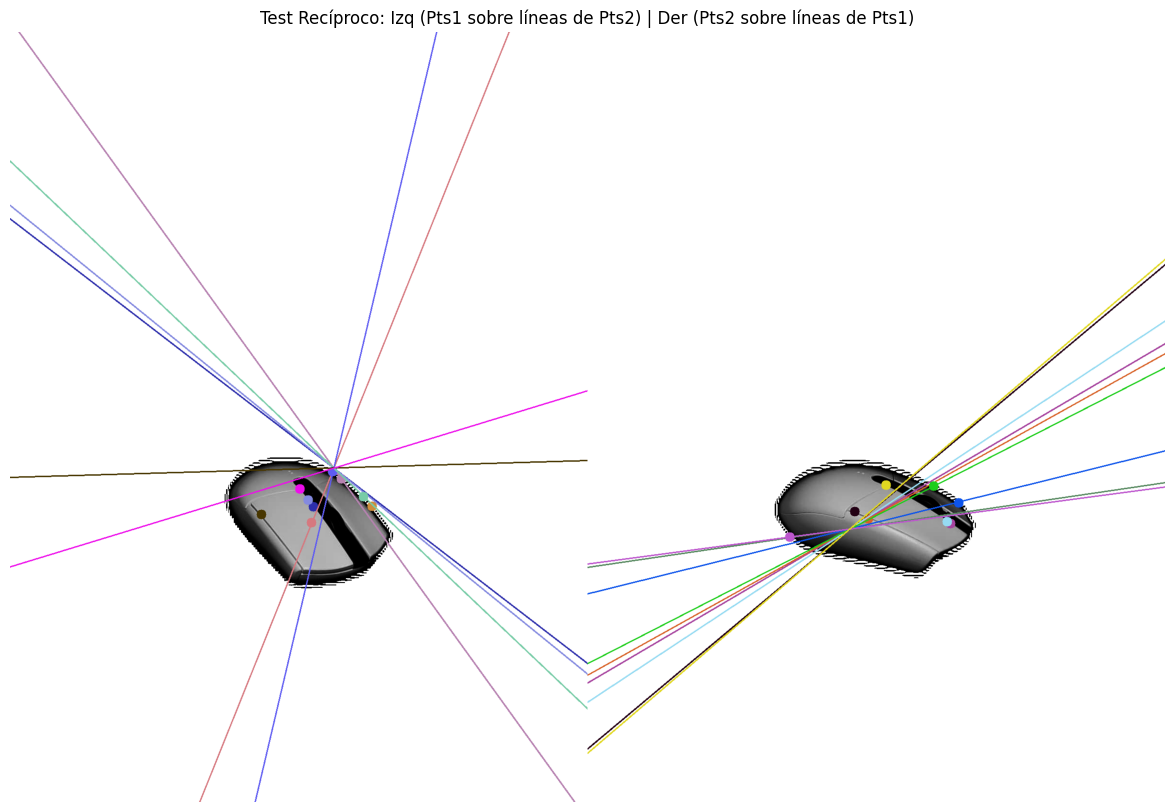

In [129]:
# 1. Calculamos F y seleccionamos una muestra aleatoria
F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)

# Tomamos 10 índices al azar para no llenar la pantalla de rayas
import random
indices = random.sample(range(len(pts1)), 10)
p1_sample = pts1[indices]
p2_sample = pts2[indices]

# 2. Cálculo de líneas recíprocas
# Líneas en Img1 (correspondientes a puntos de Img2) -> whichImage=2
lines1 = cv.computeCorrespondEpilines(p2_sample.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
# Líneas en Img2 (correspondientes a puntos de Img1) -> whichImage=1
lines2 = cv.computeCorrespondEpilines(p1_sample.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

# 3. Función auxiliar de dibujo (reutilizable)
def dibujar_epilineas(img, lines, pts):
    h, w = img.shape[:2]
    out_img = cv.cvtColor(img, cv.COLOR_GRAY2RGB)
    
    for r, pt in zip(lines, pts):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        # Dibujar línea: ax + by + c = 0  => y = -(c + ax)/b
        x0, y0 = 0, int(-r[2]/r[1])
        x1, y1 = w, int(-(r[2]+r[0]*w)/r[1])
        cv.line(out_img, (x0, y0), (x1, y1), color, 2)
        # Dibujar el punto (debe caer sobre la línea)
        cv.circle(out_img, tuple(int(x) for x in pt), 10, color, -1)
    return out_img

# 4. Visualización Recíproca
img1_epilines = dibujar_epilineas(img1, lines1, p1_sample) # Puntos en Img1 vs Líneas de Img2
img2_epilines = dibujar_epilineas(img2, lines2, p2_sample) # Puntos en Img2 vs Líneas de Img1

# Mostrar lado a lado
final_concat = np.hstack((img1_epilines, img2_epilines))

plt.figure(figsize=(20, 10))
plt.title("Test Recíproco: Izq (Pts1 sobre líneas de Pts2) | Der (Pts2 sobre líneas de Pts1)")
plt.imshow(final_concat)
plt.axis('off')
plt.show()

In [131]:
def Sfm(im1, im2, K):
 
    # 1. Obtener Puntos Emparejados
    pts1, pts2, kp1, kp2, good_matches = feature_and_matching(im1, im2)

    # 2. Estimación de la Matriz Esencial (E) y Filtro RANSAC
    # La Matriz Esencial relaciona la geometría epipolar entre dos vistas.
    # RANSAC filtra los puntos erróneos (outliers) para un cálculo robusto.
    # mask: Indica qué puntos pasaron el filtro RANSAC.
    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.99, threshold=1.0)

    # 4. Recuperación de la Pose (R, t)
    # Se descompone la matriz esencial para obtener la rotación (R) y traslación (t) 
    # que definen la pose de la segunda cámara relativa a la primera.
    # pose_mask: Filtra los puntos que tienen sentido físico (delante de ambas cámaras).
    _, R, t, pose_mask = cv.recoverPose(E, pts1, pts2, K)

    mask_final = mask.ravel() & pose_mask.ravel()
    pts1 = pts1[mask_final]
    pts2 = pts2[mask_final]
    # 5. Definición de las Matrices de Proyección (P1 y P2)
    # P = K * [R | t]
    
    # La primera cámara (P1) está en el origen del sistema de coordenadas mundial.
    P1 = np.hstack((np.eye(3), np.zeros((3, 1)))) # P1 = K * [I | 0]
    P1 = K @ P1
    
    # La segunda cámara (P2) tiene la pose relativa R y t.
    P2 = np.hstack((R, t)) # P2 = K * [R | t]
    P2 = K @ P2

    # 6. Triangulación 3D
    # La triangulación encuentra la posición 3D (X, Y, Z, W) donde se cruzan los 
    # rayos de las dos cámaras para los puntos correspondientes.
    
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)

    # 7. Conversión a Coordenadas Homogéneas (X, Y, Z)
    # Normalizamos por la coordenada W (última fila) para obtener las coordenadas 3D.
    pts3d = pts4d[:3] / pts4d[3]

    return pts3d.T.copy()


In [132]:
import plotly.graph_objects as go

#1. En primer lugar definimos la matriz intrínseca K para las imágenes
img1 = imgs_clean[0]
img2 = imgs_clean[1]

h, w = img1.shape[:2]
focal_length = 1200
pixel_size = 0.112
fx = focal_length / pixel_size
fy = focal_length / pixel_size
cx, cy = w / 2, h / 2
K = np.array([[fx, 0, cx],
                      [0, fy, cy],
                      [0, 0, 1]])
# 1. Ejecutamos Sfm

puntos_3d = Sfm(img1, img2, K)

# Añadimos más imágenes al proceso usando la primera como referencia
for i in range(2,11):
    img2 = imgs_clean[i]
    puntos = Sfm(img1, img2,K)
    puntos_3d= np.vstack((puntos_3d,puntos))

# --- FASE DE LIMPIEZA Y FILTRADO AVANZADO ---
print(f"--- DATOS DE RECONSTRUCCIÓN (FILTRADO) ---")
print(f"Total puntos generados (inicial): {len(puntos_3d)}")

# 2. Paso Básico: Eliminar puntos nulos o infinitos (Errores de división/cálculo)
mascara_validos = np.isfinite(puntos_3d).any(axis=1)
puntos_limpios = puntos_3d[mascara_validos]
print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

# 3. Paso Avanzado: Filtro de Percentil (Outlier Removal)
# Definimos los umbrales: 1% inferior y 99% superior (eliminamos el 2% más extremo)
p_low = 1  # 1% de los puntos más cercanos/negativos
p_high = 99 # 1% de los puntos más lejanos/positivos

# Calcular los umbrales de percentil para cada coordenada (X, Y, Z)
min_x, max_x = np.percentile(puntos_limpios[:, 0], [p_low, p_high])
min_y, max_y = np.percentile(puntos_limpios[:, 1], [p_low, p_high])
min_z, max_z = np.percentile(puntos_limpios[:, 2], [p_low, p_high])

# Crear una máscara que mantiene solo los puntos dentro de estos límites
filtro_percentil = (
    (puntos_limpios[:, 0] > min_x) & (puntos_limpios[:, 0] < max_x) &
    (puntos_limpios[:, 1] > min_y) & (puntos_limpios[:, 1] < max_y) 
)

# Aplicar la máscara final
puntos_finales = puntos_limpios[filtro_percentil]

print(f"Rango de Profundidad (Z) Limpio: {puntos_finales[:, 2].min():.2f} a {puntos_finales[:, 2].max():.2f}")
print(f"Puntos finales después de filtrar: {len(puntos_finales)}")
print(f"---------------------------------------------------")

# 4. Visualización con graph_objects
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',          # Usamos otra escala de color para variar
        opacity=0.8
    )
)])

fig.update_layout(
    title="Nube de Puntos 3D",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()

--- DATOS DE RECONSTRUCCIÓN (FILTRADO) ---
Total puntos generados (inicial): 425
Puntos tras eliminar Inf/NaN: 425
Rango de Profundidad (Z) Limpio: -4.44 a 3.79
Puntos finales después de filtrar: 402
---------------------------------------------------


## Sfm para más de 2 imágenes: PnP (Perspective n Points)

La Perspectiva de n puntos es un algoritmo que busca la posible aplicación del Sfm para más de 2 vistas. Se trata de un proceso en el que los puntos 3D calculados para 2 imágenes son comparados con los puntos característicos de la siguiente para así hacer una tercera matriz de rotación. Esto se realizará con el método implementado en OpenCV "solvePnP()"

In [125]:
def PnP(im_list, K):
    # Implementación del algoritmo PnP usando OpenCV
    # pts3d: Matriz Nx3 de puntos 3D conocidos
    # pts2d: Matriz Nx2 de puntos 2D correspondientes en la imagen
    # K: Matriz intrínseca de la cámara

    img1 = im_list[-1]
    img2 = im_list[0]
    pts3d_dict, P1, P2 = Sfm(img1, img2, K)


    for i in range(1, len(im_list)):
        dist_coeffs = None
        img1 = img2
        img2 = im_list[i]
        
        pts3d = np.array([p["3D_point"] for p in pts3d_dict])
        des_pts = np.array([p["des2"] for p in pts3d_dict])
        pts2 , des2 = cv.SIFT_create().detectAndCompute(img2, None)

        bf = cv.BFMatcher()
        matches = bf.knnMatch(des2, des_pts,k=2)
        good_matches = []
        ratio_threshold = 0.7 
        for m, n in matches:
            if m.distance < n.distance * ratio_threshold:
                good_matches.append(m)
        
        pts3d_act = np.float32([pts3d[p.trainIdx] for p in good_matches])

        _ , rvec, t = cv.solvePnP(pts3d_act.reshape(-1,1,3),  pts2.reshape(-1,1,2) ,K, dist_coeffs, flags=cv.SOLVEPNP_ITERATIVE)

        R, _ = cv.Rodrigues(rvec)
        
        P1 = P2

        P2 = np.hstack((R, t)) # P2 = K * [R | t]
        P2 = K @ P2


        pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)

        pts = pts4d[:3] / pts4d[3]
        pts3d = np.vstack((pts3d, pts.T))
        P1=P2

    return pts3d.copy()

In [126]:
puntos_3d = PnP(imgs_clean, K)

# --- FASE DE LIMPIEZA Y FILTRADO AVANZADO ---
print(f"--- DATOS DE RECONSTRUCCIÓN (FILTRADO) ---")
print(f"Total puntos generados (inicial): {len(puntos_3d)}")

# 2. Paso Básico: Eliminar puntos nulos o infinitos (Errores de división/cálculo)
mascara_validos = np.isfinite(puntos_3d).any(axis=1)
puntos_limpios = puntos_3d[mascara_validos]
print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

# 3. Paso Avanzado: Filtro de Percentil (Outlier Removal)
# Definimos los umbrales: 1% inferior y 99% superior (eliminamos el 2% más extremo)
p_low = 1  # 1% de los puntos más cercanos/negativos
p_high = 99 # 1% de los puntos más lejanos/positivos

# Calcular los umbrales de percentil para cada coordenada (X, Y, Z)
min_x, max_x = np.percentile(puntos_limpios[:, 0], [p_low, p_high])
min_y, max_y = np.percentile(puntos_limpios[:, 1], [p_low, p_high])
min_z, max_z = np.percentile(puntos_limpios[:, 2], [p_low, p_high])

# Crear una máscara que mantiene solo los puntos dentro de estos límites
filtro_percentil = (
    (puntos_limpios[:, 0] > min_x) & (puntos_limpios[:, 0] < max_x) &
    (puntos_limpios[:, 1] > min_y) & (puntos_limpios[:, 1] < max_y) 
)

# Aplicar la máscara final
puntos_finales = puntos_limpios[filtro_percentil]

print(f"Rango de Profundidad (Z) Limpio: {puntos_finales[:, 2].min():.2f} a {puntos_finales[:, 2].max():.2f}")
print(f"Puntos finales después de filtrar: {len(puntos_finales)}")
print(f"---------------------------------------------------")

# 4. Visualización con graph_objects
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',          # Usamos otra escala de color para variar
        opacity=0.8
    )
)])

fig.update_layout(
    title="Nube de Puntos 3D",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show()

AttributeError: 'tuple' object has no attribute 'reshape'